# Metodologia per il calcolo dell'Indice di Deprivazione Italiano

## Applicazione alle sezioni di censimento 2011

Questo notebook descrive e implementa, passo dopo passo, la metodologia utilizzata per costruire l'**Indice di Deprivazione Italiano ridotto (IDI)** a livello di sezione di censimento.

L'output dell'elaborazione sarà successivamente impiegato nel progetto *EV Charge Desert* come informazione socioeconomica per differenziare la propensione alla presenza di auto elettriche tra sezioni appartenenti alla stessa provincia.

Il notebook si concentra esclusivamente sulla costruzione dell'IDI. La ripartizione delle auto elettriche costituisce una fase successiva e non viene eseguita qui.

### Obiettivi

1. controllare integrità, struttura e copertura territoriale del CSV;
2. identificare le sezioni per cui l'IDI è calcolabile;
3. costruire le quattro componenti disponibili nei dati pubblici 2011;
4. standardizzare le componenti con uno z-score robusto;
5. sommare le componenti standardizzate;
6. controllare e limitare gli outlier estremi;
7. ottenere IDI, affluenza socioeconomica, rango e quintile nazionale;
8. esportare un file utilizzabile nella successiva ripartizione delle EV.

### File richiesto

`sezioni_censimento_2011_ridotto(1).csv` oppure la copia allegata con nome `sezioni_censimento_2011_ridotto(1)(1).csv`.

## Passaggio 1 — Definizione dell'IDI

L'Indice di Deprivazione Italiano misura lo svantaggio socioeconomico relativo di una piccola area territoriale. La metodologia originale comprende cinque dimensioni:

1. bassa istruzione;
2. disoccupazione;
3. non proprietà dell'abitazione;
4. sovraffollamento abitativo;
5. famiglie monogenitoriali.

La quinta componente non è disponibile nel file pubblico standard del Censimento 2011. Viene quindi costruito un **IDI ridotto a quattro componenti**, dichiarando esplicitamente questa limitazione.

Le variabili utilizzate sono:

| Componente | Variabili | Formula |
|---|---|---|
| Bassa istruzione | `P49`, `P50`, `P46` | $(P49 + P50) / P46$ |
| Disoccupazione | `P62`, `P60` | $P62 / P60$ |
| Famiglie in affitto | `A46`, `PF1` | $A46 / PF1$ |
| Affollamento | `PF2`, `A44` | $PF2 / A44$ |

Interpretazione delle variabili:

- `P46`: popolazione residente di almeno 6 anni;
- `P49`: popolazione con licenza media inferiore;
- `P50`: popolazione con licenza elementare;
- `P60`: popolazione di almeno 15 anni appartenente alle forze di lavoro;
- `P62`: persone disoccupate in cerca di nuova occupazione;
- `A46`: famiglie residenti in alloggi in affitto;
- `PF1`: famiglie residenti totali;
- `PF2`: componenti delle famiglie residenti;
- `A44`: superficie complessiva, in metri quadrati, delle abitazioni occupate da residenti.

> `A44` non è l'area geografica della sezione: rappresenta la superficie interna delle abitazioni e viene usata soltanto nella componente di affollamento.

In [1]:
# Parametri modificabili
from pathlib import Path

# Il primo nome corrisponde all'ultima copia allegata; il secondo al nome usato nel progetto.
CSV_FILENAMES = [
    "sezioni_censimento_2011_ridotto(1)(1).csv",
    "sezioni_censimento_2011_ridotto(1).csv",
]
CSV_SEPARATOR = ","

# L'outlier positivo dell'IDI viene limitato al percentile 99,9.
WINSOR_UPPER_Q = 0.999

# Serve solo come flag diagnostico: le sezioni con meno di 50 residenti non sono eliminate dall'IDI.
LOW_POPULATION_THRESHOLD = 50

# Il calcolo nazionale richiede tutte le 20 regioni.
REQUIRE_ALL_20_REGIONS = True

# File prodotti dal notebook.
OUTPUT_DIR = Path("output_idi")
EXPORT_COMPRESSED_CSV = True


In [2]:
# Librerie e funzioni di supporto
import csv
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    from IPython.display import display
except ImportError:
    def display(value):
        print(value)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")


def resolve_csv_path(filenames):
    # Cerca il CSV nella cartella del notebook e nelle cartelle upload adiacenti.
    cwd = Path.cwd()
    directories = [cwd, cwd / "upload", cwd.parent / "upload", cwd.parent.parent / "upload"]
    for filename in filenames:
        for directory in directories:
            candidate = directory / filename
            if candidate.exists():
                return candidate.resolve()
    raise FileNotFoundError(
        "CSV non trovato. Collocare il file nella stessa cartella del notebook "
        "oppure aggiornare CSV_FILENAMES."
    )


def normalize_code(series, width):
    # Conserva gli identificativi territoriali come stringhe con gli zeri iniziali.
    return (
        series.astype("string")
        .str.strip()
        .str.replace(r"\.0$", "", regex=True)
        .str.zfill(width)
    )


def robust_parameters(series):
    # Restituisce mediana e IQR, verificando che l'IQR sia positivo.
    clean = series.dropna()
    median = float(clean.median())
    iqr = float(clean.quantile(0.75) - clean.quantile(0.25))
    if not np.isfinite(iqr) or iqr <= 0:
        raise ValueError("IQR nullo o non valido: impossibile standardizzare la componente.")
    return median, iqr


def percentile_to_quintile(percentile_rank):
    # Converte un rango percentile in quintili 1-5.
    return np.ceil(percentile_rank * 5).clip(1, 5).astype("Int64")


## Passaggio 2 — Caricamento e verifica del dataset

Prima del calcolo si controllano:

- numero di righe e colonne;
- presenza delle variabili necessarie;
- unicità di `SEZ2011`;
- copertura di tutte le 20 regioni;
- completezza strutturale dell'ultima riga;
- presenza di valori mancanti o negativi nelle variabili utilizzate.

Gli identificativi vengono letti come stringhe per non perdere gli zeri iniziali:

- `PROCOM`: 6 cifre;
- `SEZ2011`: 13 cifre;
- `NSEZ`: 7 cifre.

In [3]:
# Caricamento e validazione iniziale
csv_path = resolve_csv_path(CSV_FILENAMES)
print(f"File utilizzato: {csv_path}")

identifier_dtypes = {
    "CODREG": "Int64",
    "CODPRO": "Int64",
    "CODCOM": "Int64",
    "PROCOM": "string",
    "SEZ2011": "string",
    "NSEZ": "string",
}

df = pd.read_csv(
    csv_path,
    sep=CSV_SEPARATOR,
    dtype=identifier_dtypes,
    low_memory=False,
)

required_columns = {
    "CODREG", "REGIONE", "CODPRO", "PROVINCIA", "CODCOM", "COMUNE",
    "PROCOM", "SEZ2011", "NSEZ",
    "P1", "P46", "P49", "P50", "P60", "P62", "A44", "PF2", "A46", "PF1",
}
missing_columns = sorted(required_columns.difference(df.columns))
if missing_columns:
    raise KeyError(f"Colonne necessarie mancanti: {missing_columns}")

df["PROCOM"] = normalize_code(df["PROCOM"], 6)
df["SEZ2011"] = normalize_code(df["SEZ2011"], 13)
df["NSEZ"] = normalize_code(df["NSEZ"], 7)

numeric_columns = ["P1", "P46", "P49", "P50", "P60", "P62", "A44", "PF2", "A46", "PF1"]
for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

if df["SEZ2011"].duplicated().any():
    duplicate_examples = df.loc[df["SEZ2011"].duplicated(keep=False), "SEZ2011"].head().tolist()
    raise ValueError(f"SEZ2011 non è univoco. Esempi: {duplicate_examples}")

# Controllo dell'ultima riga per intercettare eventuali file troncati.
with csv_path.open("rb") as handle:
    header_line = handle.readline().decode("utf-8-sig")
    header_fields = next(csv.reader([header_line], delimiter=CSV_SEPARATOR))
    handle.seek(0, 2)
    end = handle.tell()
    handle.seek(max(0, end - 16_384))
    tail_text = handle.read().decode("utf-8", errors="replace")
    tail_lines = [line for line in tail_text.splitlines() if line.strip()]
    last_fields = next(csv.reader([tail_lines[-1]], delimiter=CSV_SEPARATOR))

tail_row_complete = len(last_fields) == len(header_fields)
observed_regions = set(df["CODREG"].dropna().astype(int).unique())
expected_regions = set(range(1, 21))
missing_regions = sorted(expected_regions - observed_regions)

if REQUIRE_ALL_20_REGIONS and (missing_regions or not tail_row_complete):
    raise ValueError(
        f"Copertura nazionale incompleta. Regioni mancanti: {missing_regions}; "
        f"ultima riga completa: {tail_row_complete}."
    )

initial_checks = pd.DataFrame({
    "controllo": [
        "Record nel dataset", "Colonne", "Regioni", "Comuni", "SEZ2011 duplicati",
        "Ultima riga completa", "Valori mancanti nelle variabili IDI", "Valori negativi",
    ],
    "risultato": [
        len(df), df.shape[1], len(observed_regions), df["PROCOM"].nunique(),
        int(df["SEZ2011"].duplicated().sum()), tail_row_complete,
        int(df[numeric_columns].isna().sum().sum()), int(df[numeric_columns].lt(0).sum().sum()),
    ],
})
display(initial_checks)
display(df.head(3))


File utilizzato: /workspace/scratch/35a11f094ce2/upload/sezioni_censimento_2011_ridotto(1)(1).csv
                             controllo risultato
0                   Record nel dataset    366863
1                              Colonne        47
2                              Regioni        20
3                               Comuni      8092
4                    SEZ2011 duplicati         0
5                 Ultima riga completa      True
6  Valori mancanti nelle variabili IDI         0
7                      Valori negativi         0
   CODREG   REGIONE  CODPRO PROVINCIA  CODCOM COMUNE  PROCOM        SEZ2011  \
0       1  Piemonte       1    Torino       1  Agliè  001001  0010010000001   
1       1  Piemonte       1    Torino       1  Agliè  001001  0010010000002   
2       1  Piemonte       1    Torino       1  Agliè  001001  0010010000006   

      NSEZ  ACE  CODLOC  CODASC   P1  P46  P49  P50  P60  P62    A44  PF2  \
0  0000001    0   10001     NaN  805  752  240  196  355   31  3693

## Passaggio 3 — Definizione dell'universo di calcolo

L'IDI non è definibile per una sezione priva di residenti o con un denominatore nullo. Una sezione è quindi considerata **calcolabile** quando:

$$
P1>0,\quad P46>0,\quad P60>0,\quad PF1>0,\quad A44>0
$$

e i numeratori `P49`, `P50`, `P62`, `PF2` e `A46` sono presenti e non negativi.

Scelte metodologiche:

- le sezioni con `P1 = 0` restano nel file finale, ma ricevono IDI mancante;
- le sezioni con meno di 50 residenti non vengono eliminate, perché il calcolo documentato dell'IDI utilizza tutte le sezioni abitate con denominatori validi;
- viene comunque creato `flag_bassa_popolazione`, utile nella successiva fase di ripartizione EV;
- le sezioni censuarie speciali vengono identificate e mantenute per riprodurre l'universo censuario, ma dovranno essere escluse dall'allocazione spaziale delle EV.

In [4]:
# Flag di qualità e universo di calcolo
nsez_numeric = pd.to_numeric(df["NSEZ"], errors="coerce")
df["flag_sezione_speciale"] = (
    nsez_numeric.isin([9_999_999, 9_999_998, 7_777_777])
    | nsez_numeric.between(8_888_881, 8_888_889)
)

df["flag_abitata"] = df["P1"].gt(0)
df["flag_bassa_popolazione"] = df["P1"].between(1, LOW_POPULATION_THRESHOLD - 1)

denominator_columns = ["P46", "P60", "PF1", "A44"]
numerator_columns = ["P49", "P50", "P62", "PF2", "A46"]

df["flag_denominatori_validi"] = df[denominator_columns].gt(0).all(axis=1)
df["flag_numeratori_validi"] = (
    df[numerator_columns].notna().all(axis=1)
    & df[numerator_columns].ge(0).all(axis=1)
)
df["flag_IDI_calcolabile"] = (
    df["flag_abitata"]
    & df["flag_denominatori_validi"]
    & df["flag_numeratori_validi"]
)

df["motivo_IDI_non_calcolabile"] = np.select(
    [
        ~df["flag_abitata"],
        df["P46"].le(0) | df["P46"].isna(),
        df["P60"].le(0) | df["P60"].isna(),
        df["PF1"].le(0) | df["PF1"].isna(),
        df["A44"].le(0) | df["A44"].isna(),
        ~df["flag_numeratori_validi"],
    ],
    [
        "popolazione_zero",
        "P46_non_valido",
        "P60_non_valido",
        "PF1_non_valido",
        "A44_non_valido",
        "numeratore_non_valido",
    ],
    default="",
)

valid_idi = df["flag_IDI_calcolabile"]

universe_summary = pd.DataFrame({
    "metrica": [
        "Sezioni totali", "Sezioni abitate", "Sezioni IDI calcolabili",
        "Sezioni abitate senza IDI", "Sezioni con 1-49 residenti", "Sezioni speciali",
    ],
    "numero": [
        len(df), int(df["flag_abitata"].sum()), int(valid_idi.sum()),
        int((df["flag_abitata"] & ~valid_idi).sum()),
        int(df["flag_bassa_popolazione"].sum()), int(df["flag_sezione_speciale"].sum()),
    ],
})
universe_summary["percentuale_sul_totale"] = universe_summary["numero"] / len(df)
display(universe_summary)
display(
    df.loc[~valid_idi, "motivo_IDI_non_calcolabile"]
    .value_counts()
    .rename_axis("motivo")
    .to_frame("sezioni")
)


                      metrica  numero  percentuale_sul_totale
0              Sezioni totali  366863                  1.0000
1             Sezioni abitate  349033                  0.9514
2     Sezioni IDI calcolabili  341354                  0.9305
3   Sezioni abitate senza IDI    7679                  0.0209
4  Sezioni con 1-49 residenti  139183                  0.3794
5            Sezioni speciali    1107                  0.0030
                  sezioni
motivo                   
popolazione_zero    17830
P60_non_valido       6153
A44_non_valido       1083
PF1_non_valido        437
P46_non_valido          6


## Passaggio 4 — Calcolo delle componenti grezze

Per ogni sezione calcolabile vengono costruite quattro proporzioni o rapporti.

### 4.1 Bassa istruzione

$$
x_{istruzione,i}=\frac{P49_i+P50_i}{P46_i}
$$

### 4.2 Disoccupazione

$$
x_{disoccupazione,i}=\frac{P62_i}{P60_i}
$$

### 4.3 Famiglie in affitto

$$
x_{affitto,i}=\frac{A46_i}{PF1_i}
$$

La variabile è utilizzata come proxy della non proprietà. Il suo significato deve essere interpretato con prudenza, perché nei dati del progetto ha mostrato una relazione controintuitiva con il reddito comunale.

### 4.4 Affollamento

$$
x_{affollamento,i}=\frac{PF2_i}{A44_i}
$$

Valori più elevati indicano un maggior numero di componenti per metro quadrato di superficie abitativa.

In [5]:
# Calcolo delle quattro componenti grezze
df["componente_bassa_istruzione"] = np.where(
    valid_idi,
    (df["P49"] + df["P50"]) / df["P46"],
    np.nan,
)
df["componente_disoccupazione"] = np.where(
    valid_idi, df["P62"] / df["P60"], np.nan
)
df["componente_non_proprieta"] = np.where(
    valid_idi, df["A46"] / df["PF1"], np.nan
)
df["componente_affollamento"] = np.where(
    valid_idi, df["PF2"] / df["A44"], np.nan
)

component_columns = [
    "componente_bassa_istruzione",
    "componente_disoccupazione",
    "componente_non_proprieta",
    "componente_affollamento",
]

component_summary = df.loc[valid_idi, component_columns].describe(
    percentiles=[0.001, 0.01, 0.25, 0.5, 0.75, 0.99, 0.999]
).T
display(component_summary)


                                   count   mean    std    min   0.1%     1%  \
componente_bassa_istruzione 341,354.0000 0.4988 0.1613 0.0000 0.0000 0.0000   
componente_disoccupazione   341,354.0000 0.0715 0.0869 0.0000 0.0000 0.0000   
componente_non_proprieta    341,354.0000 0.1564 0.1787 0.0000 0.0000 0.0000   
componente_affollamento     341,354.0000 0.0247 0.0115 0.0011 0.0057 0.0105   

                               25%    50%    75%    99%  99.9%    max  
componente_bassa_istruzione 0.4071 0.5079 0.5957 1.0000 1.0000 1.0000  
componente_disoccupazione   0.0000 0.0554 0.1000 0.3750 1.0000 1.0000  
componente_non_proprieta    0.0208 0.1111 0.2215 0.9270 1.0000 1.0000  
componente_affollamento     0.0205 0.0240 0.0277 0.0476 0.0836 2.5789  


## Passaggio 5 — Standardizzazione robusta

Le quattro componenti hanno distribuzioni e scale differenti. Prima di sommarle è necessario renderle confrontabili.

Si utilizza lo **z-score robusto**:

$$
z_{ik}=\frac{x_{ik}-\operatorname{mediana}(x_k)}{IQR(x_k)}
$$

dove:

$$
IQR(x_k)=Q_{75}(x_k)-Q_{25}(x_k)
$$

Questo approccio è preferito allo z-score classico basato su media e deviazione standard perché la componente di affollamento contiene una coda estrema: il suo massimo supera ampiamente il 99,9° percentile.

Mediane e IQR vengono calcolati congiuntamente su tutte le sezioni IDI-calcolabili delle 20 regioni. In questo modo ogni sezione è confrontata con lo stesso riferimento nazionale.

In [6]:
# Standardizzazione robusta nazionale
z_columns = []
benchmark_rows = []

for component in component_columns:
    median, iqr = robust_parameters(df.loc[valid_idi, component])
    z_column = component.replace("componente_", "z_")
    df[z_column] = np.where(
        valid_idi,
        (df[component] - median) / iqr,
        np.nan,
    )
    z_columns.append(z_column)
    benchmark_rows.append({
        "componente": component,
        "mediana_nazionale": median,
        "IQR_nazionale": iqr,
    })

benchmark_table = pd.DataFrame(benchmark_rows)
display(benchmark_table)

# Somma dei quattro z-score: IDI alto = maggiore deprivazione.
df["IDI_ridotto_grezzo"] = df[z_columns].sum(axis=1, min_count=4)

idi_raw_summary = df.loc[valid_idi, "IDI_ridotto_grezzo"].describe(
    percentiles=[0.001, 0.01, 0.25, 0.5, 0.75, 0.99, 0.999]
)
display(idi_raw_summary.to_frame("IDI_ridotto_grezzo"))


                    componente  mediana_nazionale  IQR_nazionale
0  componente_bassa_istruzione             0.5079         0.1887
1    componente_disoccupazione             0.0554         0.1000
2     componente_non_proprieta             0.1111         0.2007
3      componente_affollamento             0.0240         0.0072
       IDI_ridotto_grezzo
count        341,354.0000
mean               0.4394
std                2.4670
min               -6.9761
0.1%              -6.0704
1%                -4.1351
25%               -0.7981
50%                0.2101
75%                1.3572
99%                7.4347
99.9%             13.2034
max              356.3542


## Passaggio 6 — Winsorizing dell'IDI

L'utilizzo dello z-score robusto limita l'influenza degli outlier, ma non modifica materialmente i valori estremi. Per evitare che poche sezioni dominino un successivo impiego quantitativo dell'indice, viene mantenuto l'IDI grezzo e viene costruita anche una versione winsorizzata.

La coda superiore viene limitata al 99,9° percentile nazionale:

$$
IDI^{winsor}_i=\min\left(IDI_i,Q_{99,9\%}(IDI)\right)
$$

La scelta interviene sulla coda di elevata deprivazione, quella interessata dagli outlier positivi dell'affollamento. L'indice grezzo resta disponibile per trasparenza e audit.

In [7]:
# Winsorizing superiore al percentile 99,9
idi_upper_bound = float(df.loc[valid_idi, "IDI_ridotto_grezzo"].quantile(WINSOR_UPPER_Q))
df["IDI_ridotto_winsor"] = df["IDI_ridotto_grezzo"].clip(upper=idi_upper_bound)

# Segno invertito: valori alti indicano maggiore benessere relativo.
df["affluenza_IDI"] = -df["IDI_ridotto_winsor"]

# Rango nazionale di deprivazione e quintili.
df["percentile_deprivazione"] = df["IDI_ridotto_winsor"].rank(
    method="average", pct=True
)
df["quintile_deprivazione"] = percentile_to_quintile(
    df["percentile_deprivazione"]
)

# Variabile già orientata per il futuro impiego: 1 = maggior benessere relativo.
df["percentile_benessere"] = 1 - df["percentile_deprivazione"]

winsor_summary = pd.DataFrame({
    "metrica": [
        "Soglia winsor 99,9%", "Minimo IDI grezzo", "Massimo IDI grezzo",
        "Minimo IDI winsor", "Massimo IDI winsor",
    ],
    "valore": [
        idi_upper_bound,
        df.loc[valid_idi, "IDI_ridotto_grezzo"].min(),
        df.loc[valid_idi, "IDI_ridotto_grezzo"].max(),
        df.loc[valid_idi, "IDI_ridotto_winsor"].min(),
        df.loc[valid_idi, "IDI_ridotto_winsor"].max(),
    ],
})
display(winsor_summary)

quintile_summary = (
    df.loc[valid_idi, "quintile_deprivazione"]
    .value_counts()
    .sort_index()
    .rename_axis("quintile")
    .to_frame("sezioni")
)
display(quintile_summary)


               metrica   valore
0  Soglia winsor 99,9%  13.2034
1    Minimo IDI grezzo  -6.9761
2   Massimo IDI grezzo 356.3542
3    Minimo IDI winsor  -6.9761
4   Massimo IDI winsor  13.2034
          sezioni
quintile         
1           68270
2           68271
3           68271
4           68271
5           68271


## Passaggio 7 — Controlli diagnostici

Prima di esportare l'indice si verificano:

- distribuzione delle componenti;
- correlazioni tra le componenti;
- distribuzione dell'IDI prima e dopo il winsorizing;
- equilibrio numerico dei quintili;
- copertura dell'IDI nelle singole regioni.

Le correlazioni non devono necessariamente essere elevate: le quattro componenti rappresentano dimensioni differenti della deprivazione. Correlazioni quasi perfette segnalerebbero invece una duplicazione dell'informazione.

                             componente_bassa_istruzione  \
componente_bassa_istruzione                       1.0000   
componente_disoccupazione                         0.0630   
componente_non_proprieta                         -0.0730   
componente_affollamento                           0.1970   

                             componente_disoccupazione  \
componente_bassa_istruzione                     0.0630   
componente_disoccupazione                       1.0000   
componente_non_proprieta                        0.2210   
componente_affollamento                         0.2410   

                             componente_non_proprieta  componente_affollamento  
componente_bassa_istruzione                   -0.0730                   0.1970  
componente_disoccupazione                      0.2210                   0.2410  
componente_non_proprieta                       1.0000                   0.1860  
componente_affollamento                        0.1860                   1.0000  
   

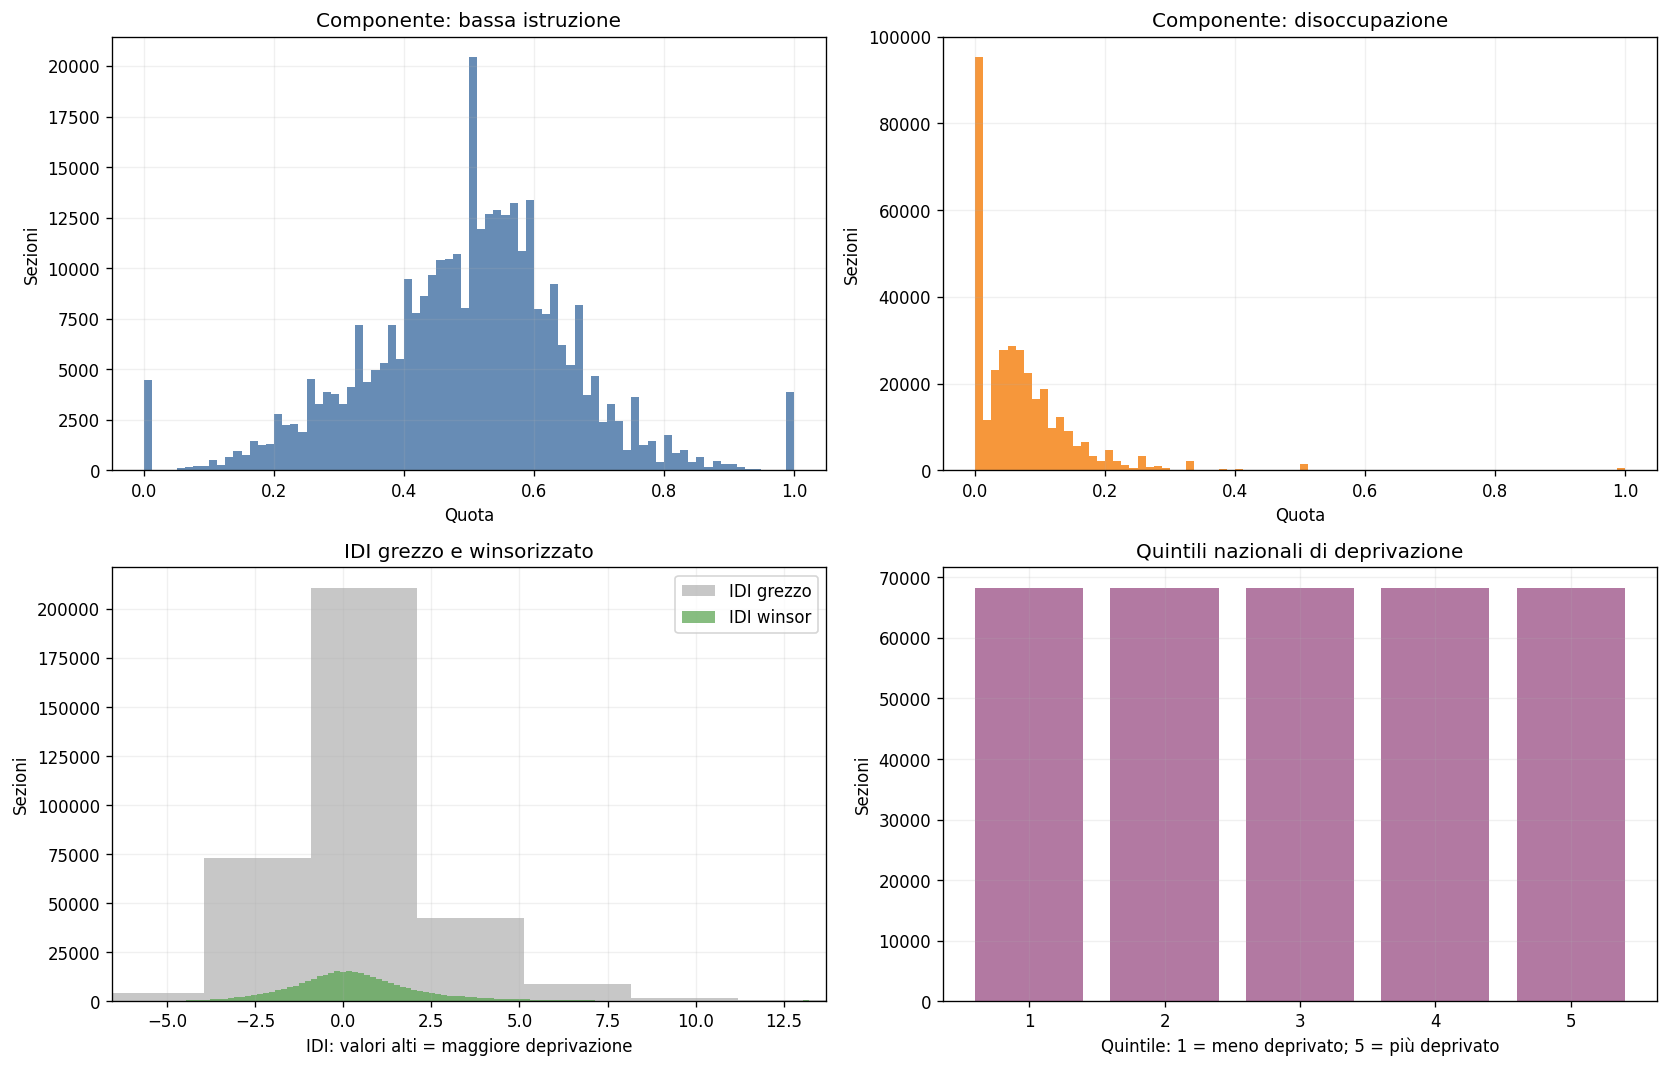

In [8]:
# Correlazioni e copertura regionale
component_correlations = df.loc[valid_idi, component_columns].corr(method="spearman")
display(component_correlations.round(3))

regional_quality = (
    df.groupby(["CODREG", "REGIONE"], dropna=False)
    .agg(
        sezioni=("SEZ2011", "size"),
        sezioni_abitate=("flag_abitata", "sum"),
        sezioni_IDI_calcolabile=("flag_IDI_calcolabile", "sum"),
    )
    .reset_index()
    .sort_values("CODREG")
)
regional_quality["copertura_IDI_su_abitate"] = (
    regional_quality["sezioni_IDI_calcolabile"]
    / regional_quality["sezioni_abitate"].replace(0, np.nan)
)
display(regional_quality)

# Grafici diagnostici
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0, 0].hist(
    df.loc[valid_idi, "componente_bassa_istruzione"],
    bins=80, color="#4C78A8", alpha=0.85,
)
axes[0, 0].set_title("Componente: bassa istruzione")
axes[0, 0].set_xlabel("Quota")
axes[0, 0].set_ylabel("Sezioni")

axes[0, 1].hist(
    df.loc[valid_idi, "componente_disoccupazione"],
    bins=80, color="#F58518", alpha=0.85,
)
axes[0, 1].set_title("Componente: disoccupazione")
axes[0, 1].set_xlabel("Quota")
axes[0, 1].set_ylabel("Sezioni")

axes[1, 0].hist(
    df.loc[valid_idi, "IDI_ridotto_grezzo"],
    bins=120, color="#999999", alpha=0.55, label="IDI grezzo",
)
axes[1, 0].hist(
    df.loc[valid_idi, "IDI_ridotto_winsor"],
    bins=120, color="#54A24B", alpha=0.70, label="IDI winsor",
)
axes[1, 0].set_xlim(
    df.loc[valid_idi, "IDI_ridotto_winsor"].quantile(0.001) - 0.5,
    df.loc[valid_idi, "IDI_ridotto_winsor"].max() + 0.5,
)
axes[1, 0].set_title("IDI grezzo e winsorizzato")
axes[1, 0].set_xlabel("IDI: valori alti = maggiore deprivazione")
axes[1, 0].set_ylabel("Sezioni")
axes[1, 0].legend()

axes[1, 1].bar(
    quintile_summary.index.astype(str),
    quintile_summary["sezioni"],
    color="#B279A2",
)
axes[1, 1].set_title("Quintili nazionali di deprivazione")
axes[1, 1].set_xlabel("Quintile: 1 = meno deprivato; 5 = più deprivato")
axes[1, 1].set_ylabel("Sezioni")

for axis in axes.flat:
    axis.grid(alpha=0.18)

fig.tight_layout()
plt.show()


## Passaggio 8 — Esportazione dell'IDI

Il file finale mantiene una riga per ogni sezione, comprese quelle per cui l'IDI non è calcolabile. Questa scelta preserva l'universo territoriale e rende trasparenti le esclusioni.

Le colonne principali prodotte sono:

- `flag_IDI_calcolabile`;
- quattro componenti grezze;
- quattro z-score robusti;
- `IDI_ridotto_grezzo`;
- `IDI_ridotto_winsor`;
- `affluenza_IDI`;
- `percentile_deprivazione`;
- `quintile_deprivazione`;
- `percentile_benessere`.

Per il successivo impiego sulle EV è preferibile utilizzare `percentile_benessere` oppure il quintile trasformato, perché sono limitati e non risentono della scala estrema dell'IDI grezzo.

L'IDI non deve essere utilizzato come unico peso: nella fase successiva dovrà modificare una base demografica, ad esempio la popolazione in età di guida, e dovranno essere applicati vincoli di plausibilità.

In [9]:
# Esportazione dei risultati e dei parametri metodologici
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

output_columns = [
    "CODREG", "REGIONE", "CODPRO", "PROVINCIA", "CODCOM", "COMUNE",
    "PROCOM", "SEZ2011", "NSEZ", "P1",
    "P46", "P49", "P50", "P60", "P62", "A44", "PF2", "A46", "PF1",
    "flag_abitata", "flag_bassa_popolazione", "flag_sezione_speciale",
    "flag_denominatori_validi", "flag_numeratori_validi", "flag_IDI_calcolabile",
    "motivo_IDI_non_calcolabile",
    *component_columns,
    *z_columns,
    "IDI_ridotto_grezzo", "IDI_ridotto_winsor", "affluenza_IDI",
    "percentile_deprivazione", "quintile_deprivazione", "percentile_benessere",
]

idi_output_path = OUTPUT_DIR / "indice_deprivazione_sezioni_2011.csv.gz"
if EXPORT_COMPRESSED_CSV:
    df[output_columns].to_csv(idi_output_path, index=False, compression="gzip")

regional_output_path = OUTPUT_DIR / "qualita_IDI_per_regione.csv"
regional_quality.to_csv(regional_output_path, index=False)

metadata = {
    "input_file": csv_path.name,
    "records": int(len(df)),
    "regions": sorted(int(value) for value in observed_regions),
    "inhabited_sections": int(df["flag_abitata"].sum()),
    "valid_idi_sections": int(valid_idi.sum()),
    "coverage_on_inhabited": float(valid_idi.sum() / df["flag_abitata"].sum()),
    "components": {
        "bassa_istruzione": "(P49 + P50) / P46",
        "disoccupazione": "P62 / P60",
        "non_proprieta": "A46 / PF1",
        "affollamento": "PF2 / A44",
    },
    "standardization": "robust_z_score_median_IQR",
    "robust_benchmarks": benchmark_table.set_index("componente").to_dict("index"),
    "winsor_upper_quantile": WINSOR_UPPER_Q,
    "winsor_upper_bound": idi_upper_bound,
}

metadata_output_path = OUTPUT_DIR / "parametri_metodologia_IDI.json"
with metadata_output_path.open("w", encoding="utf-8") as handle:
    json.dump(metadata, handle, ensure_ascii=False, indent=2)

print("File prodotti:")
if EXPORT_COMPRESSED_CSV:
    print(f"- {idi_output_path.resolve()}")
print(f"- {regional_output_path.resolve()}")
print(f"- {metadata_output_path.resolve()}")


File prodotti:
- /workspace/scratch/35a11f094ce2/outputs/idi_method/output_idi/indice_deprivazione_sezioni_2011.csv.gz
- /workspace/scratch/35a11f094ce2/outputs/idi_method/output_idi/qualita_IDI_per_regione.csv
- /workspace/scratch/35a11f094ce2/outputs/idi_method/output_idi/parametri_metodologia_IDI.json


In [10]:
# Verifiche finali automatiche
assert len(observed_regions) == 20
assert df["SEZ2011"].is_unique
assert tail_row_complete
assert df.loc[valid_idi, component_columns].notna().all().all()
assert df.loc[valid_idi, z_columns].notna().all().all()
assert df.loc[valid_idi, "IDI_ridotto_winsor"].notna().all()
assert df.loc[valid_idi, "quintile_deprivazione"].between(1, 5).all()
assert df.loc[~valid_idi, "IDI_ridotto_grezzo"].isna().all()
assert int(quintile_summary["sezioni"].sum()) == int(valid_idi.sum())
if EXPORT_COMPRESSED_CSV:
    assert idi_output_path.exists() and idi_output_path.stat().st_size > 0
assert regional_output_path.exists() and metadata_output_path.exists()

print("Tutte le verifiche sono state superate.")
print(f"Sezioni abitate: {int(df['flag_abitata'].sum()):,}")
print(f"Sezioni con IDI calcolabile: {int(valid_idi.sum()):,}")
print(f"Copertura sulle sezioni abitate: {valid_idi.sum() / df['flag_abitata'].sum():.2%}")


Tutte le verifiche sono state superate.
Sezioni abitate: 349,033
Sezioni con IDI calcolabile: 341,354
Copertura sulle sezioni abitate: 97.80%


## Conclusione metodologica

L'algoritmo produce un IDI ridotto a quattro componenti, confrontabile sull'intero territorio nazionale e accompagnato da informazioni sufficienti per verificarne la costruzione.

La variabile da interpretare come indice principale è:

```text
IDI_ridotto_winsor
```

- valori elevati: maggiore deprivazione;
- valori bassi: minore deprivazione.

Per il successivo utilizzo nella ripartizione delle auto elettriche sono disponibili anche:

```text
affluenza_IDI
percentile_benessere
quintile_deprivazione
```

La fase successiva dovrà utilizzare queste variabili come correttivo della popolazione potenzialmente automobilistica. In altri termini, l'IDI rappresenterà la **propensione socioeconomica**, mentre la popolazione rappresenterà la **dimensione della domanda potenziale**.

### Limiti da dichiarare

1. manca la componente delle famiglie monogenitoriali;
2. la quota di famiglie in affitto può aggiungere rumore e dovrà essere sottoposta a un controllo di sensibilità;
3. l'IDI è costruito con dati 2011 e va interpretato come caratteristica strutturale di lungo periodo;
4. le sezioni piccole presentano rapporti più instabili, anche se la standardizzazione robusta e il futuro uso dei ranghi ne limitano l'impatto;
5. le sezioni speciali devono essere escluse dalla successiva allocazione geografica delle EV.

# Parte II — Ripartizione delle auto elettriche con l'IDI

Questa seconda parte trasforma l'IDI in una variabile utilizzabile per disaggregare un totale provinciale di auto elettriche tra le sezioni di censimento.

Il principio fondamentale è che l'IDI **non sostituisce la popolazione**. Il numero potenziale di auto dipende innanzitutto dalla dimensione demografica della sezione; l'IDI interviene soltanto come correttivo della propensione socioeconomica all'adozione di un veicolo elettrico.

Per ogni sezione $i$ appartenente alla provincia $p$ si utilizzano:

- $D_i$: popolazione in età di guida (`popolazione_eta_guida_stimata`);
- $B_i$: rango nazionale di benessere (`percentile_benessere`), compreso tra 0 e 1;
- $N_i$: popolazione residente (`P1`);
- $EV_p$: totale osservato di auto elettriche della provincia.

La procedura deve soddisfare simultaneamente quattro condizioni:

1. nessuna auto viene attribuita a sezioni senza residenti, senza popolazione in età di guida o censuarie speciali;
2. l'IDI modifica, ma non domina, la base demografica;
3. una sezione non può superare un limite di plausibilità demografica;
4. la somma delle stime sezionali coincide esattamente con il totale provinciale.

## Passaggio 9 — Moltiplicatore socioeconomico e sezioni piccole

L'IDI viene utilizzato attraverso `percentile_benessere`, orientato in modo che 1 rappresenti il maggior benessere relativo e 0 il maggior livello di deprivazione.

Per attenuare l'instabilità dell'IDI nelle sezioni con pochi residenti si introduce un fattore di affidabilità:

$$
R_i=\frac{N_i}{N_i+k}
$$

e quindi:

$$
M_i=1+\beta R_i(2B_i-1)
$$

Il peso non normalizzato è:

$$
W_i=D_iM_i
$$

Parametri iniziali raccomandati:

- $\beta=0{,}30$: l'IDI può modificare il peso pro capite al massimo del 30%;
- $k=50$: sotto i 50 residenti l'effetto dell'IDI viene fortemente attenuato.

Se l'IDI non è calcolabile, si assegna $B_i=0{,}5$: il moltiplicatore diventa neutrale e la sezione non viene eliminata.

In [11]:
# Parametri della ripartizione EV
# Inserire in questo file una riga per provincia con CODPRO ed EV_PROVINCIALE.
EV_PROVINCIALI_PATH = OUTPUT_DIR / "auto_elettriche_per_provincia.csv"
EV_CODE_COLUMN = "CODPRO"
EV_TOTAL_COLUMN = "EV_PROVINCIALE"

# Scenari suggeriti: 0.15 prudente, 0.30 centrale, 0.50 forte.
BETA_IDI_EV = 0.30

# Attenuazione dell'IDI nelle sezioni piccole.
K_POPOLAZIONE_EV = 50

# Base demografica preferita.
BASE_DEMOGRAFICA_EV = "popolazione_eta_guida_stimata"

# Massimo iniziale: una EV per residente stimato in età di guida.
# Se il dato provinciale contiene una quota importante di flotte aziendali,
# tale componente deve essere trattata separatamente oppure il cap va motivato.
MAX_EV_PER_PERSONA_GUIDA = 1.0

# False mantiene valori attesi decimali; True applica i maggiori resti.
EV_OUTPUT_INTERO = False


In [12]:
# Creazione del template provinciale, se l'input EV non è ancora disponibile
province_template = (
    df[["CODREG", "CODPRO", "PROVINCIA"]]
    .drop_duplicates()
    .sort_values(["CODREG", "CODPRO"])
    .reset_index(drop=True)
)
province_template[EV_TOTAL_COLUMN] = pd.NA

if not EV_PROVINCIALI_PATH.exists():
    province_template.to_csv(EV_PROVINCIALI_PATH, index=False)
    print("Creato il template dei totali EV provinciali:")
    print(EV_PROVINCIALI_PATH.resolve())
    print("Compilare la colonna EV_PROVINCIALE e rieseguire dalla Parte II.")
else:
    print(f"File provinciale già presente: {EV_PROVINCIALI_PATH.resolve()}")

display(province_template.head())
print(f"Province/codici provinciali nel template: {len(province_template)}")


Creato il template dei totali EV provinciali:
/workspace/scratch/35a11f094ce2/outputs/idi_method/output_idi/auto_elettriche_per_provincia.csv
Compilare la colonna EV_PROVINCIALE e rieseguire dalla Parte II.
   CODREG  CODPRO PROVINCIA EV_PROVINCIALE
0       1       1    Torino           <NA>
1       1       2  Vercelli           <NA>
2       1       3    Novara           <NA>
3       1       4     Cuneo           <NA>
4       1       5      Asti           <NA>
Province/codici provinciali nel template: 110


## Passaggio 10 — Normalizzazione provinciale

Il totale provinciale viene distribuito in proporzione ai pesi:

$$
EV_i^*=EV_p\frac{W_i}{\sum_{j\in p}W_j}
$$

La normalizzazione è effettuata separatamente in ogni provincia, mentre il rango di benessere rimane nazionale. Di conseguenza tutte le province conservano il proprio totale osservato, ma le sezioni più popolose e relativamente più benestanti ricevono un peso maggiore.

Non si usa direttamente `affluenza_IDI` perché può assumere valori negativi e presenta una scala meno interpretabile. Il rango `percentile_benessere` garantisce invece un correttivo positivo, continuo e limitato.

## Passaggio 11 — Cap e redistribuzione dell'eccedenza

La prima stima proporzionale potrebbe, in casi estremi, superare la base demografica della sezione. Viene quindi imposto:

$$
CAP_i=D_i\times c
$$

con $c=1$ come valore iniziale: al massimo una EV per residente stimato in età di guida.

Quando una sezione supera il cap:

1. la sua stima viene fissata al cap;
2. l'eccedenza viene redistribuita tra le altre sezioni della provincia secondo i pesi originari;
3. l'operazione viene ripetuta fino alla completa allocazione del totale provinciale.

Se la somma dei cap provinciali è inferiore al totale EV osservato, l'algoritmo si arresta: il totale non è compatibile con il vincolo e non deve essere forzato silenziosamente.

In [13]:
# Funzioni per pesi, cap, redistribuzione e arrotondamento
def prepara_pesi_ev(
    sections,
    beta=BETA_IDI_EV,
    k_population=K_POPOLAZIONE_EV,
    base_column=BASE_DEMOGRAFICA_EV,
    max_ev_per_person=MAX_EV_PER_PERSONA_GUIDA,
):
    # Costruisce un peso demografico corretto dall'IDI senza eliminare gli IDI mancanti.
    if not 0 <= beta < 1:
        raise ValueError("beta deve essere compreso tra 0 incluso e 1 escluso.")
    if k_population < 0 or max_ev_per_person <= 0:
        raise ValueError("k_population e max_ev_per_person devono essere positivi.")
    if base_column not in sections.columns:
        raise KeyError(f"Colonna demografica non trovata: {base_column}")

    out = sections.copy()
    out["base_demografica_EV"] = (
        pd.to_numeric(out[base_column], errors="coerce")
        .fillna(0)
        .clip(lower=0)
    )
    out["rango_benessere_EV"] = (
        pd.to_numeric(out["percentile_benessere"], errors="coerce")
        .fillna(0.5)
        .clip(0, 1)
    )
    population = pd.to_numeric(out["P1"], errors="coerce").fillna(0).clip(lower=0)
    out["fattore_affidabilita_IDI"] = np.where(
        population.add(k_population).gt(0),
        population / (population + k_population),
        0.0,
    )
    out["moltiplicatore_IDI_EV"] = (
        1
        + beta
        * out["fattore_affidabilita_IDI"]
        * (2 * out["rango_benessere_EV"] - 1)
    )

    special = out["flag_sezione_speciale"].fillna(False).astype(bool)
    out["flag_eleggibile_EV"] = (
        population.gt(0)
        & out["base_demografica_EV"].gt(0)
        & ~special
    )
    out["peso_EV"] = np.where(
        out["flag_eleggibile_EV"],
        out["base_demografica_EV"] * out["moltiplicatore_IDI_EV"],
        0.0,
    )
    out["cap_EV_sezione"] = np.where(
        out["flag_eleggibile_EV"],
        out["base_demografica_EV"] * max_ev_per_person,
        0.0,
    )
    return out


def allocazione_pesata_con_cap(weights, caps, total, tolerance=1e-9):
    # Distribuisce un totale secondo i pesi e redistribuisce iterativamente oltre-cap.
    weights = np.asarray(weights, dtype=float)
    caps = np.asarray(caps, dtype=float)
    total = float(total)

    if weights.shape != caps.shape:
        raise ValueError("weights e caps devono avere la stessa dimensione.")
    if total < -tolerance or np.any(weights < 0) or np.any(caps < 0):
        raise ValueError("Totale, pesi e cap devono essere non negativi.")
    if total <= tolerance:
        return np.zeros_like(weights)
    if caps.sum() + tolerance < total:
        raise ValueError(
            f"Totale provinciale {total:g} superiore alla capacità complessiva {caps.sum():g}."
        )

    allocation = np.zeros_like(weights)
    remaining = total
    active = (weights > 0) & (caps > 0)

    while remaining > tolerance:
        residual_capacity = caps - allocation
        candidates = active & (residual_capacity > tolerance)
        if not candidates.any():
            raise ValueError("Capacità esaurita prima della completa allocazione.")

        candidate_weights = weights[candidates]
        if candidate_weights.sum() <= tolerance:
            candidate_weights = residual_capacity[candidates]

        proposal = remaining * candidate_weights / candidate_weights.sum()
        candidate_capacity = residual_capacity[candidates]
        over_cap = proposal > candidate_capacity + tolerance

        candidate_positions = np.flatnonzero(candidates)
        if not over_cap.any():
            allocation[candidate_positions] += proposal
            remaining = 0.0
        else:
            capped_positions = candidate_positions[over_cap]
            assigned = residual_capacity[capped_positions]
            allocation[capped_positions] += assigned
            remaining -= assigned.sum()
            active[capped_positions] = False

    return allocation


def arrotonda_maggiori_resti(values, total, caps):
    # Converte valori attesi in interi preservando il totale e rispettando i cap.
    values = np.asarray(values, dtype=float)
    integer_caps = np.floor(np.asarray(caps, dtype=float) + 1e-12).astype(int)
    integer_total = int(round(float(total)))
    if not np.isclose(float(total), integer_total):
        raise ValueError("Per l'output intero il totale provinciale deve essere intero.")

    rounded = np.floor(values + 1e-12).astype(int)
    rounded = np.minimum(rounded, integer_caps)
    missing = integer_total - int(rounded.sum())
    if missing < 0:
        raise AssertionError("Arrotondamento iniziale superiore al totale.")

    fractions = values - np.floor(values)
    candidates = np.flatnonzero(rounded < integer_caps)
    order = candidates[np.argsort(-fractions[candidates], kind="stable")]
    if missing > len(order):
        raise ValueError("Cap interi insufficienti per completare l'arrotondamento.")
    rounded[order[:missing]] += 1
    return rounded


def ripartisci_ev_per_provincia(
    sections,
    provincial_totals,
    code_column=EV_CODE_COLUMN,
    total_column=EV_TOTAL_COLUMN,
    integer_output=EV_OUTPUT_INTERO,
):
    # Applica l'intera procedura provincia per provincia.
    required = {code_column, total_column}
    missing = required.difference(provincial_totals.columns)
    if missing:
        raise KeyError(f"Colonne mancanti nel file provinciale: {sorted(missing)}")

    totals = provincial_totals[[code_column, total_column]].copy()
    totals[code_column] = pd.to_numeric(totals[code_column], errors="raise").astype(int)
    totals[total_column] = pd.to_numeric(totals[total_column], errors="raise")
    if totals[code_column].duplicated().any():
        raise ValueError("Il file EV contiene codici provinciali duplicati.")
    if totals[total_column].isna().any() or totals[total_column].lt(0).any():
        raise ValueError("I totali EV devono essere presenti e non negativi.")

    out = prepara_pesi_ev(sections)
    out[code_column] = pd.to_numeric(out[code_column], errors="raise").astype(int)
    totals_map = totals.set_index(code_column)[total_column]

    observed_codes = set(out[code_column].unique())
    total_codes = set(totals_map.index)
    missing_totals = observed_codes.difference(total_codes)
    unknown_totals = total_codes.difference(observed_codes)
    if missing_totals:
        raise ValueError(f"Totali EV mancanti per CODPRO: {sorted(missing_totals)}")
    if unknown_totals:
        raise ValueError(f"CODPRO non presenti nelle sezioni: {sorted(unknown_totals)}")

    out["EV_PROVINCIALE"] = out[code_column].map(totals_map).astype(float)
    out["quota_peso_provincia"] = 0.0
    out["EV_stimate_sezione"] = 0.0

    for province_code, row_index in out.groupby(code_column, sort=False).groups.items():
        index = list(row_index)
        total = float(totals_map.loc[province_code])
        province_weights = out.loc[index, "peso_EV"].to_numpy(dtype=float)
        province_caps = out.loc[index, "cap_EV_sezione"].to_numpy(dtype=float)

        if total > 0 and province_weights.sum() <= 0:
            raise ValueError(f"Nessun peso eleggibile nella provincia {province_code}.")
        if province_weights.sum() > 0:
            out.loc[index, "quota_peso_provincia"] = (
                province_weights / province_weights.sum()
            )

        allocation = allocazione_pesata_con_cap(
            province_weights,
            province_caps,
            total,
        )
        if integer_output:
            allocation = arrotonda_maggiori_resti(allocation, total, province_caps)
        out.loc[index, "EV_stimate_sezione"] = allocation

    return out


In [14]:
# Autotest delle funzioni: conservazione, cap e arrotondamento
test_weights = np.array([2.0, 3.0, 5.0])
test_caps = np.array([1.0, 10.0, 10.0])
test_total = 12

test_float = allocazione_pesata_con_cap(test_weights, test_caps, test_total)
test_integer = arrotonda_maggiori_resti(test_float, test_total, test_caps)

assert np.isclose(test_float.sum(), test_total)
assert np.all(test_float <= test_caps + 1e-9)
assert test_integer.sum() == test_total
assert np.all(test_integer <= np.floor(test_caps).astype(int))

print("Autotest superato.")
print("Allocazione decimale:", np.round(test_float, 4))
print("Allocazione intera:", test_integer)


Autotest superato.
Allocazione decimale: [1.    4.125 6.875]
Allocazione intera: [1 4 7]


## Passaggio 12 — Esecuzione, output e verifiche

Il file `auto_elettriche_per_provincia.csv` deve contenere una riga per ogni codice provinciale presente nelle sezioni e almeno queste colonne:

| CODPRO | EV_PROVINCIALE |
|---:|---:|
| 1 | totale osservato |
| ... | ... |

Il notebook crea automaticamente un template con i codici e i nomi delle province. Fino a quando la colonna `EV_PROVINCIALE` non è compilata, la cella seguente non esegue la ripartizione e non genera errori.

L'output decimale rappresenta un **valore atteso** ed è metodologicamente preferibile per analisi e mappe. Se sono indispensabili conteggi interi, impostare `EV_OUTPUT_INTERO = True`: il metodo dei maggiori resti conserva il totale di ciascuna provincia.

Controlli obbligatori dopo l'esecuzione:

- somma delle stime uguale al totale provinciale;
- nessun valore negativo;
- nessuna sezione sopra il cap;
- valore zero per sezioni non eleggibili;
- nessun codice provinciale mancante o duplicato.

In [15]:
# Esecuzione reale, attivata quando il template provinciale è compilato
ev_allocation = None
ev_allocation_path = OUTPUT_DIR / "stima_EV_per_sezione_con_IDI.csv.gz"

ev_prov = pd.read_csv(EV_PROVINCIALI_PATH)
required_ev_columns = {EV_CODE_COLUMN, EV_TOTAL_COLUMN}

if not required_ev_columns.issubset(ev_prov.columns):
    print(
        "Ripartizione non eseguita: il file provinciale deve contenere "
        f"le colonne {sorted(required_ev_columns)}."
    )
elif ev_prov[EV_TOTAL_COLUMN].isna().any():
    missing_count = int(ev_prov[EV_TOTAL_COLUMN].isna().sum())
    print(
        f"Ripartizione non eseguita: compilare {EV_TOTAL_COLUMN} "
        f"per tutte le province ({missing_count} valori mancanti)."
    )
else:
    ev_allocation = ripartisci_ev_per_provincia(
        df,
        ev_prov,
        integer_output=EV_OUTPUT_INTERO,
    )

    provincial_check = (
        ev_allocation.groupby(["CODPRO", "PROVINCIA"], as_index=False)
        .agg(
            EV_input=("EV_PROVINCIALE", "first"),
            EV_ripartite=("EV_stimate_sezione", "sum"),
            sezioni_eleggibili=("flag_eleggibile_EV", "sum"),
            peso_totale=("peso_EV", "sum"),
            capacita_totale=("cap_EV_sezione", "sum"),
        )
    )
    provincial_check["differenza"] = (
        provincial_check["EV_ripartite"] - provincial_check["EV_input"]
    )

    assert np.allclose(
        provincial_check["EV_ripartite"],
        provincial_check["EV_input"],
        atol=1e-7,
    )
    assert ev_allocation["EV_stimate_sezione"].ge(-1e-9).all()
    assert (
        ev_allocation["EV_stimate_sezione"]
        <= ev_allocation["cap_EV_sezione"] + 1e-7
    ).all()
    assert ev_allocation.loc[
        ~ev_allocation["flag_eleggibile_EV"], "EV_stimate_sezione"
    ].abs().le(1e-9).all()

    allocation_columns = [
        "CODREG", "REGIONE", "CODPRO", "PROVINCIA", "CODCOM", "COMUNE",
        "PROCOM", "SEZ2011", "P1", BASE_DEMOGRAFICA_EV,
        "flag_IDI_calcolabile", "flag_sezione_speciale",
        "percentile_deprivazione", "percentile_benessere",
        "rango_benessere_EV", "fattore_affidabilita_IDI",
        "moltiplicatore_IDI_EV", "flag_eleggibile_EV", "peso_EV",
        "quota_peso_provincia", "cap_EV_sezione", "EV_PROVINCIALE",
        "EV_stimate_sezione",
    ]
    ev_allocation[allocation_columns].to_csv(
        ev_allocation_path,
        index=False,
        compression="gzip",
    )

    display(provincial_check.head(10))
    print(f"Output EV creato: {ev_allocation_path.resolve()}")
    print("Tutti i controlli provinciali sono stati superati.")


Ripartizione non eseguita: compilare EV_PROVINCIALE per tutte le province (110 valori mancanti).


## Passaggio 13 — Analisi di sensibilità e interpretazione

Il parametro $\beta$ non può essere identificato utilizzando soltanto i totali provinciali: tali totali vengono infatti rispettati per costruzione qualunque sia il valore di $\beta$. Si raccomanda quindi di confrontare almeno tre scenari:

| Scenario | $\beta$ | Intervallo massimo del moltiplicatore |
|---|---:|---:|
| Prudente | 0,15 | 0,85–1,15 |
| Centrale | 0,30 | 0,70–1,30 |
| Forte | 0,50 | 0,50–1,50 |

La scelta definitiva dovrebbe essere validata aggregando le stime sezionali a livello comunale e confrontandole, quando possibile, con dati EV comunali osservati. In assenza di questi dati, lo scenario centrale è una scelta esplorativa trasparente, non una stima calibrata.

È inoltre opportuno verificare:

1. quante sezioni raggiungono il cap;
2. quanto cambia l'ordinamento delle sezioni nei tre scenari;
3. l'effetto di una versione dell'IDI senza la componente `non_proprieta`;
4. l'eventuale separazione delle flotte aziendali dalla domanda residenziale;
5. la compatibilità temporale e territoriale tra sezioni 2011 e geometrie o popolazione di anni successivi.